## Polychronous Chain

On va créer ici un graphe dynamique qui va relier N neurons entre eux de telle sorte à ce que chaque neurone soit connecté à M autres neurones

In [1]:
from dataclasses import dataclass
@dataclass
class Config:
    """Paramètres contrôlant la taille, la cadence et la surveillance de l'anneau."""
    N: int = 13  # Nombre de neurones dans l'anneau
    M: int = 3   # Noàmbre de connexions
    P: float = 2.1 # temps en secondes pour une période complète
    seed:int = 42+2 # seed du RNG

c= Config()
c

Config(N=13, M=3, P=2.1, seed=44)

La première idée est de créer une liste ordonnée d'activation des $N$ neurones 

In [2]:
import numpy as np

np.random.randint(c.N)

8

In [3]:
idxs = np.random.randint(c.N, size=c.N)
idxs

array([10, 10,  3,  5,  6,  9,  0,  3,  8,  4,  9,  2,  6])

Pour commencer, faisons en sorte que chaque neurone soit activé une et une seule fois:

In [4]:
idxs = np.random.permutation(c.N)
idxs

array([10,  3,  1,  2,  4,  6,  5,  0,  7,  8, 12,  9, 11])

In [5]:
np.roll(idxs, 0)[:(c.M)]

array([10,  3,  1])

In [6]:
np.roll(idxs, -1)[:(c.M)]

array([3, 1, 2])

In [7]:
np.roll(idxs, -2)[:(c.M)]

array([1, 2, 4])

ça veut dire que chaque neurone est connecté aux $M$ suivant:


In [8]:
outboxes = {}
for i, idx in enumerate(idxs):
    outboxes[int(idx)] = np.roll(idxs, -i-1)[:(c.M)].tolist()
outboxes

{10: [3, 1, 2],
 3: [1, 2, 4],
 1: [2, 4, 6],
 2: [4, 6, 5],
 4: [6, 5, 0],
 6: [5, 0, 7],
 5: [0, 7, 8],
 0: [7, 8, 12],
 7: [8, 12, 9],
 8: [12, 9, 11],
 12: [9, 11, 10],
 9: [11, 10, 3],
 11: [10, 3, 1]}

Il est possible de visualiser les connexions entre les neurones.
Site web pour trouver les #HEX : https://htmlcolorcodes.com/fr/

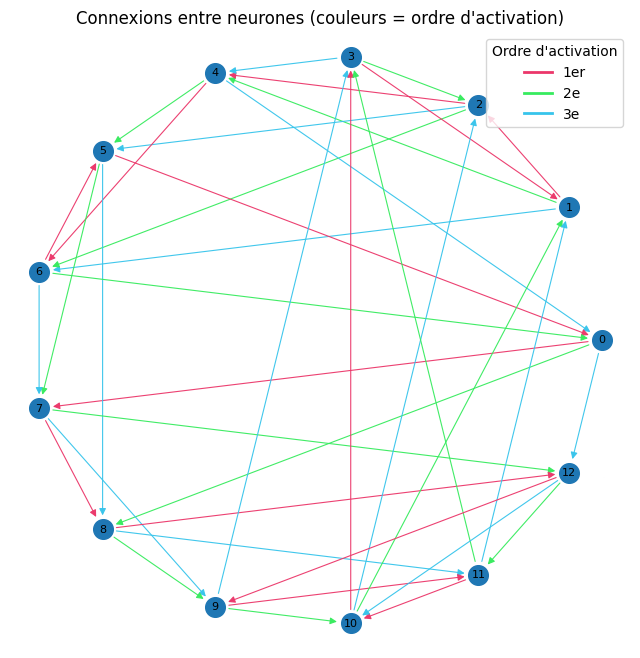

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D

def plot_outboxes(outboxes, figsize=(8, 8), with_labels=True, arrow_scale=10,
                  node_size=200, label_size=8, linewidth=0.8, max_edges=None,
                  palette=("#EB376A", "#37EB5E", "#37C4EB"), show_legend=True):
    """
    Affiche un graphe orienté où chaque clé de `outboxes` est un neurone source,
    et sa liste de valeurs sont les neurones cibles dans l'ordre d'activation.
    
    Couleurs par ordre d'activation (dans la liste des cibles) :
      - 1er  -> couleur_palette_1
      - 2e   -> couleur_palette_2
      - 3e   -> couleur_palette_3
      - 4e+  -> on recycle les couleurs, ajouter d'autres pour éviter la boucle
      FYI: Il est possible d'avoir plus de 3 couleurs dans `palette`. Pour ce faire, ajouter autant de couleurs que nécessaire.

    Paramètres principaux:
      - outboxes: dict[int, list[int]]  (défini à partir de la cellule [8])
      - palette: tuple/list de couleurs
      - show_legend: affiche une légende 1er/2e/3e
    """
    if not isinstance(outboxes, dict) or not outboxes:
        raise ValueError("`outboxes` doit être un dict non vide {source: [dest1, dest2, ...]}.")

    # Liste ordonnée des nœuds pour une disposition stable
    nodes = sorted(outboxes.keys())
    N = len(nodes)

    # Disposition circulaire
    angles = 2 * np.pi * np.arange(N) / max(N, 1)
    R = 1.0
    positions = {n: (R * np.cos(theta), R * np.sin(theta)) for n, theta in zip(nodes, angles)}

    # Figure
    fig, ax = plt.subplots(figsize=figsize)

    # Tracé des nœuds
    xs = [positions[n][0] for n in nodes]
    ys = [positions[n][1] for n in nodes]
    ax.scatter(xs, ys, s=node_size)

    # Labels au centre des nœuds
    if with_labels:
        for n in nodes:
            x, y = positions[n]
            ax.text(x, y, str(n), ha="center", va="center", fontsize=label_size)

    # Tracé des arêtes (flèches colorées selon l'ordre)
    drawn = 0
    for src in nodes:
        targets = outboxes.get(src, [])
        for j, dst in enumerate(targets):
            if dst not in positions:
                # Ignore les cibles absentes (au cas où)
                continue
            if max_edges is not None and drawn >= max_edges:
                break

            x1, y1 = positions[src]
            x2, y2 = positions[dst]

            color = palette[j % len(palette)]  # ordre d'activation -> couleur
            arrow = FancyArrowPatch(
                (x1, y1), (x2, y2),
                arrowstyle="-|>",
                mutation_scale=arrow_scale,
                shrinkA=10, shrinkB=10,
                linewidth=linewidth,
                color=color,
                alpha=0.95
            )
            ax.add_patch(arrow)
            drawn += 1

    ax.set_aspect("equal", adjustable="datalim")
    ax.axis("off")

    # Légende (optionnelle) : 1er/2e/3e
    if show_legend and len(palette) >= 3:
        legend_elems = [
            Line2D([0], [0], color=palette[0], lw=2, label="1er"),
            Line2D([0], [0], color=palette[1], lw=2, label="2e"),
            Line2D([0], [0], color=palette[2], lw=2, label="3e"),
        ]
        ax.legend(handles=legend_elems, loc="upper right", title="Ordre d'activation")

    plt.title("Connexions entre neurones (couleurs = ordre d'activation)")
    plt.show()


# Appel : pour le 9, (3 en violet, 4 en bleu marine, 5 en cyan) comme demandé.
plot_outboxes(outboxes)


Maintenant les délais sont répartis uniformément dans une période:


In [10]:
delays = np.random.uniform(0, c.P, size=c.N)
delays

array([1.33907224, 1.25646649, 0.9552046 , 1.66936687, 0.08149267,
       1.06078599, 0.56229174, 0.91721038, 0.19413451, 1.34002743,
       1.54232173, 1.04180687, 0.95865487])

On trie les valeurs.

In [11]:
delays = np.sort(delays)
delays

array([0.08149267, 0.19413451, 0.56229174, 0.91721038, 0.9552046 ,
       0.95865487, 1.04180687, 1.06078599, 1.25646649, 1.33907224,
       1.34002743, 1.54232173, 1.66936687])

Ces délais dans la période sont les temps d'écoute des neurones. Rassemblons les morceaux:

In [12]:
outboxes = {}
for i, idx in enumerate(idxs):
    outbox = np.roll(idxs, -i-1)[:(c.M)].tolist()
    times_out = np.roll(delays, -i-1)[:(c.M)]
    delays_out = (times_out-delays[i]).tolist()

    outboxes[int(idx)] = [(o, float(d)) for (o,d) in zip(outbox, delays_out)]
outboxes

{10: [(3, 0.11264184046537346),
  (1, 0.48079907224072227),
  (2, 0.8357177120471452)],
 3: [(1, 0.36815723177534876),
  (2, 0.7230758715817717),
  (4, 0.7610700898992171)],
 1: [(2, 0.3549186398064229),
  (4, 0.39291285812386834),
  (6, 0.39636313409475143)],
 2: [(4, 0.03799421831744543),
  (6, 0.041444494288328526),
  (5, 0.12459649468584177)],
 4: [(6, 0.003450275970883099),
  (5, 0.08660227636839635),
  (0, 0.10558139345829021)],
 6: [(5, 0.08315200039751325),
  (0, 0.10213111748740711),
  (7, 0.2978116110982427)],
 5: [(0, 0.01897911708989386),
  (7, 0.21465961070072948),
  (8, 0.2972653658377329)],
 0: [(7, 0.19568049361083562),
  (8, 0.278286248747839),
  (12, 0.2792414419159279)],
 7: [(8, 0.08260575513700341),
  (12, 0.08356094830509231),
  (9, 0.2858552464059301)],
 8: [(12, 0.000955193168088897),
  (9, 0.20324949126892666),
  (11, 0.3302946324284841)],
 12: [(9, 0.20229429810083777),
  (11, 0.3293394392603952),
  (10, -1.2585347657388086)],
 9: [(11, 0.12704514115955745),
 

Maintenant on peut utiliser cette routine en une fonction:

In [13]:
def get_outboxes(c):
    np.random.seed(c.seed)
    idxs = np.random.permutation(c.N)
    delays = np.random.uniform(0, c.P, size=c.N)
    delays = np.sort(delays)

    outboxes = {}
    for i, idx in enumerate(idxs):
        outbox = np.roll(idxs, -i-1)[:(c.M)].tolist()
        times_out = np.roll(delays, -i-1)[:(c.M)]
        delays_out = (times_out-delays[i]).tolist()

        outboxes[int(idx)] = [(o, float(d)) for (o,d) in zip(outbox, delays_out)]

    return outboxes

In [14]:
c = Config(N=1000, M=20)
c

Config(N=1000, M=20, P=2.1, seed=44)

In [15]:
outboxes = get_outboxes(c)
len(outboxes)

1000

In [16]:
outboxes.keys()

dict_keys([118, 19, 41, 425, 221, 758, 637, 231, 406, 848, 639, 928, 32, 281, 237, 841, 998, 117, 622, 837, 610, 212, 3, 137, 685, 90, 308, 802, 254, 609, 66, 272, 88, 910, 291, 599, 503, 201, 38, 35, 204, 881, 736, 514, 350, 68, 623, 868, 414, 64, 255, 981, 381, 996, 123, 139, 283, 404, 386, 515, 885, 0, 36, 769, 324, 276, 372, 136, 641, 20, 782, 643, 407, 933, 906, 849, 432, 499, 871, 972, 229, 960, 412, 705, 395, 693, 521, 125, 771, 180, 873, 80, 811, 233, 694, 143, 840, 763, 526, 316, 1, 246, 78, 53, 940, 390, 888, 380, 141, 181, 71, 145, 909, 658, 619, 863, 303, 681, 270, 236, 403, 427, 132, 299, 500, 119, 187, 799, 608, 712, 625, 230, 669, 506, 355, 616, 493, 449, 812, 345, 764, 284, 85, 481, 245, 656, 629, 842, 879, 659, 883, 228, 94, 547, 829, 824, 951, 175, 917, 252, 528, 81, 567, 731, 182, 73, 486, 858, 640, 243, 569, 797, 695, 715, 183, 469, 61, 748, 545, 600, 688, 363, 196, 985, 948, 911, 184, 814, 821, 920, 755, 781, 67, 206, 652, 714, 744, 671, 286, 805, 49, 479, 50, 424,

Les connexions du neurone 42:

In [17]:
outboxes[861]

[(211, 0.0023823622942475975),
 (322, 0.004016356401443266),
 (290, 0.009133310069804557),
 (737, 0.012335356758109928),
 (672, 0.019466347539249362),
 (28, 0.021949419393483494),
 (446, 0.029132990561679062),
 (34, 0.030026800446523616),
 (148, 0.03204274050619227),
 (634, 0.034482181665322464),
 (819, 0.037932555044230876),
 (383, 0.04027726024063405),
 (487, 0.04030210421940228),
 (361, 0.04163810317143524),
 (111, 0.04214499201776012),
 (248, 0.04415516133513053),
 (447, 0.044869829105687487),
 (485, 0.045159876345304495),
 (189, 0.04858910893418722),
 (388, 0.05213930244700249)]

On peut remarquer des valeurs trop courtes (5.9e-5 pour 340). On adapte le code afin d'obtenir des valeurs de délai >0.1 ms. 

In [18]:
def get_outboxes(c):
    np.random.seed(c.seed)
    idxs = np.random.permutation(c.N)
    
    D = 0.0003  # délai minimum [même unité que c.P, ici secondes]
    assert (D * c.N) < c.P, f"Infeasible: D*c.N={D*c.N} >= c.P={c.P}"

    delays = np.random.uniform(0, c.P - D * c.N, size=c.N)
    delays = np.sort(delays)
    delays += D * (np.arange(c.N) + 1)

    # (optionnel mais utile en debug) : vérifie l'espacement incluant l'intervalle circulaire entre dernier et premier
    diffs = np.diff(np.r_[delays, delays[0] + c.P])
    assert np.all(diffs >= D - 1e-12), "Espacement < D détecté"

    outboxes = {}
    for i, idx in enumerate(idxs):
        outbox = np.roll(idxs, -i-1)[:c.M].tolist()
        times_out = np.roll(delays, -i-1)[:c.M]
        delays_out = ((times_out - delays[i]) % c.P).tolist()
        outboxes[int(idx)] = [(int(o), float(d)) for (o, d) in zip(outbox, delays_out)]

    return outboxes 


In [19]:
c = Config(N=1000, M=20)
c

Config(N=1000, M=20, P=2.1, seed=44)

In [20]:
outboxes = get_outboxes(c)
len(outboxes)

1000

In [21]:
outboxes[861]

[(211, 0.0023420248236405428),
 (322, 0.004042591201236956),
 (290, 0.008728551488403902),
 (737, 0.011773162935522885),
 (672, 0.01818544074792805),
 (28, 0.020613788051557114),
 (446, 0.027071134767153282),
 (34, 0.028137257525591597),
 (148, 0.03016520614816498),
 (634, 0.03255615571313353),
 (819, 0.035813618609340736),
 (383, 0.03812336592054333),
 (487, 0.03844466075948749),
 (361, 0.039889802718372946),
 (111, 0.04062427887236564),
 (248, 0.04264728114439764),
 (447, 0.04355985351916081),
 (485, 0.04410846543883218),
 (189, 0.04734780765787461),
 (388, 0.050690830668859155)]

Le problème a été résolu. Maintenant on souhaite visualiser les temps avec les adresses sur une petite configuration. Ce graphique présentera les adresses et leurs connexions selon le temps.

In [22]:
c = Config()
c

outboxes=get_outboxes(c)

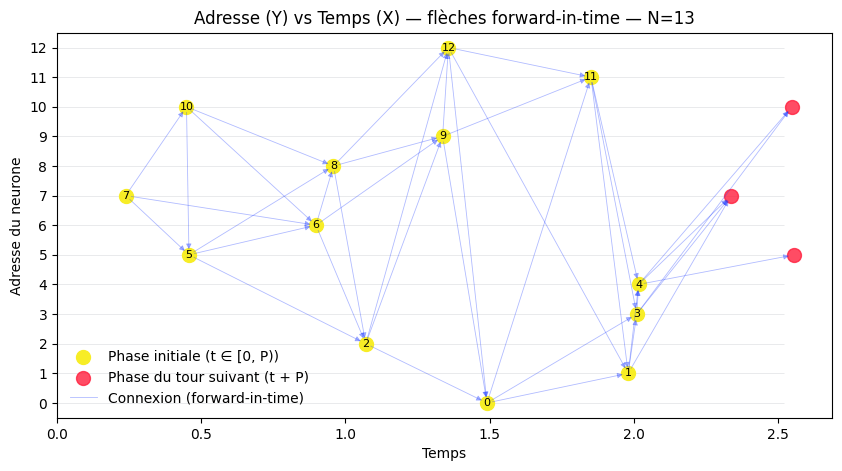

In [23]:
try:
    c  
except NameError as e:
    raise NameError(
        "La variable de configuration `c` n'est pas définie. "
        "Exécute d'abord une cellule de configuration (c = Config(...))."
    ) from e

# ---------- Reproduire la génération adresse <-> temps ----------
seed = getattr(c, "seed", None)
if seed is not None:
    np.random.seed(seed)

N = int(getattr(c, "N", 0))
if N <= 0:
    raise ValueError("`c.N` doit être un entier strictement positif.")

P = float(getattr(c, "P", 1.0))  # période/étendue temporelle (unités propres à ta config)

idxs   = np.random.permutation(N)               # adresses (neurons IDs)
delays = np.random.uniform(0, P, size=N)        # temps
delays.sort()

# Scatter data et mapping
x = delays
y = idxs
addr2time = {int(a): float(t) for a, t in zip(idxs, delays)}

# ---------- Récupération des arêtes ----------
def _edges_from_M(M):
    """Liste [(src, dst), ...] depuis une matrice d'adjacence dense ou sparse."""
    try:
        import scipy.sparse as sp
        if sp.issparse(M):
            M = M.tocoo()
            return list(zip(M.row.tolist(), M.col.tolist()))
    except Exception:
        pass
    A = np.asarray(M)
    srcs, dsts = np.nonzero(A)
    return list(zip(srcs.tolist(), dsts.tolist()))

def _edges_from_outboxes(outboxes):
    """Liste [(src, dst), ...] depuis un dict outboxes."""
    edges = []
    for s, lst in outboxes.items():
        if not lst:
            continue
        # lst peut être [dst, ...] ou [(dst, delay), ...]
        if isinstance(lst[0], tuple):
            targets = [t for (t, _) in lst]
        else:
            targets = lst
        for t in targets:
            edges.append((int(s), int(t)))
    return edges

_g = globals()
if "M" in _g:
    edges = _edges_from_M(_g["M"])
elif "outboxes" in _g:
    edges = _edges_from_outboxes(_g["outboxes"])
else:
    raise NameError("Ni `M` (cellule [30]) ni `outboxes` ne sont définis. Exécute d'abord l'une de ces cellules.")

# ---------- Paramètres de rendu ----------
arrow_alpha = 0.35
arrow_lw    = 0.6
arrow_scale = 8     # taille de tête de flèche (mutation_scale)
node_size   = 100
ghost_size  = 100
max_edges   = None  # ex: 8000 pour limiter
EPS = np.nextafter(0.0, 1.0)

# ---------- Calcul des flèches + des points futurs nécessaires ----------
future_nodes = set()
edges_to_draw = edges if max_edges is None else edges[:max_edges]
arr_specs = []  # stocke (t_src, src, t_arr, dst)

for (src, dst) in edges_to_draw:
    if src not in addr2time or dst not in addr2time:
        continue
    t_src = addr2time[src]
    t_dst = addr2time[dst]
    delta = (t_dst - t_src) % P
    if delta == 0.0:
        delta = EPS
    t_arr = t_src + delta
    arr_specs.append((t_src, src, t_arr, dst))
    if t_arr >= P:   # destination visible au tour suivant => futur point utile
        future_nodes.add(dst)

# ---------- Tracé ----------
# Préparer les points du tour suivant si nécessaires (AVANT toute utilisation)
if future_nodes:
    y_ghost = np.array(sorted(future_nodes), dtype=int)
    x_ghost = np.array([addr2time[a] + P for a in y_ghost], dtype=float)
else:
    y_ghost = np.array([], dtype=int)
    x_ghost = np.array([], dtype=float)

fig, ax = plt.subplots(figsize=(10, 5))

# Lignes horizontales (une par neurone)
XMAX = 1.2 * P              # mettre meme borne que xlim plus bas
ax.set_axisbelow(True)      # les lignes passent derrière points/flèches
for yline in range(N):      
    ax.hlines(y=yline, xmin=0.0, xmax=XMAX,
              colors="#9aa0a6", linewidth=0.6, alpha=0.25, zorder=0)
ax.set_ylim(-0.5, N - 0.5)  # centre les lignes sur les entiers


# Points initiaux - Neurones
sc_actual_node = ax.scatter(x, y, s=node_size, c="#F7ED26",
                            label="Phase initiale (t ∈ [0, P))")

# Labels dans chaque bulle (adresse du neurone)
for xx, yy in zip(x, y):
    ax.text(xx, yy, str(int(yy)), ha="center", va="center", fontsize=8, zorder=3)

# Points futurs "utiles" seulement (t + P)
if y_ghost.size:
    sc_future_node = ax.scatter(x_ghost, y_ghost, s=ghost_size, alpha=0.8,
                                label="Phase du tour suivant (t + P)",
                                c="#FF1F3D") 
else:
    sc_future_node = None

# Flèches forward-in-time
for (t_src, src, t_arr, dst) in arr_specs:
    arr = FancyArrowPatch(
        (t_src, src), (t_arr, dst),
        arrowstyle="-|>",
        mutation_scale=arrow_scale,
        shrinkA=4, shrinkB=4,
        linewidth=arrow_lw,
        alpha=arrow_alpha,
        color="#1F3DFF"
    )
    ax.add_patch(arr)

# Légende
handles = [sc_actual_node]
if sc_future_node is not None:
    handles.append(sc_future_node)
handles.append(Line2D([0], [0], color="#1F3DFF", alpha=arrow_alpha, lw=arrow_lw,
                      label="Connexion (forward-in-time)"))
ax.legend(handles=handles, loc="lower left", frameon=False)

ax.set_xlim(0, 1.28 * P) # longueur de l'axe X
ax.set_yticks(range(c.N))
ax.set_xlabel("Temps")
ax.set_ylabel("Adresse du neurone")
ax.set_title(f"Adresse (Y) vs Temps (X) — flèches forward-in-time — N={N}")
ax.grid(False)

plt.show()

Le graphique ci-dessus est une carte temporelle des neurones (adresse en Y, phase en X) où chaque point orange fixe l’instant propre d’un neurone, et chaque flèche bleue montre une connexion efférente allant jusqu’au premier instant d’écoute compatible du neurone cible (éventuellement affiché au tour suivant en vert).